In [1]:
# necessary imports for this notebook
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks') # setting style
sns.set_context('talk') # setting context
sns.set_palette('colorblind') # setting palette

In [2]:
stellar = pd.read_csv('https://raw.githubusercontent.com/dannycab/MSU_REU_ML_course/refs/heads/main/activities/data/star_classification.csv')
stellar.head()

# remove all the columns that are not needed
df_stellar = stellar[['obj_ID', 'class', 'u', 'g', 'r', 'i', 'z','redshift']]

# drop any row with negative photometric values
filter = (df_stellar['u'] >= 0) & (df_stellar['g'] >= 0) & (df_stellar['r'] >= 0) & (df_stellar['i'] >= 0) & (df_stellar['z'] >= 0)
df_stellar = df_stellar[filter]

# describe the data again
df_stellar.describe()

,obj_ID,u,g,r,i,z,redshift
count,9.999900e+04,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,1.237665e+18,22.080679,20.631583,19.645777,19.084865,18.768988,0.576667
std,8.438450e+12,2.251068,2.037384,1.854763,1.757900,1.765982,0.730709
min,1.237646e+18,10.996230,10.498200,9.822070,9.469903,9.612333,-0.009971
25%,1.237659e+18,20.352410,18.965240,18.135795,17.732280,17.460830,0.054522
50%,1.237663e+18,22.179140,21.099930,20.125310,19.405150,19.004600,0.424176
75%,1.237668e+18,23.687480,22.123775,21.044790,20.396510,19.921120,0.704172
max,1.237681e+18,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


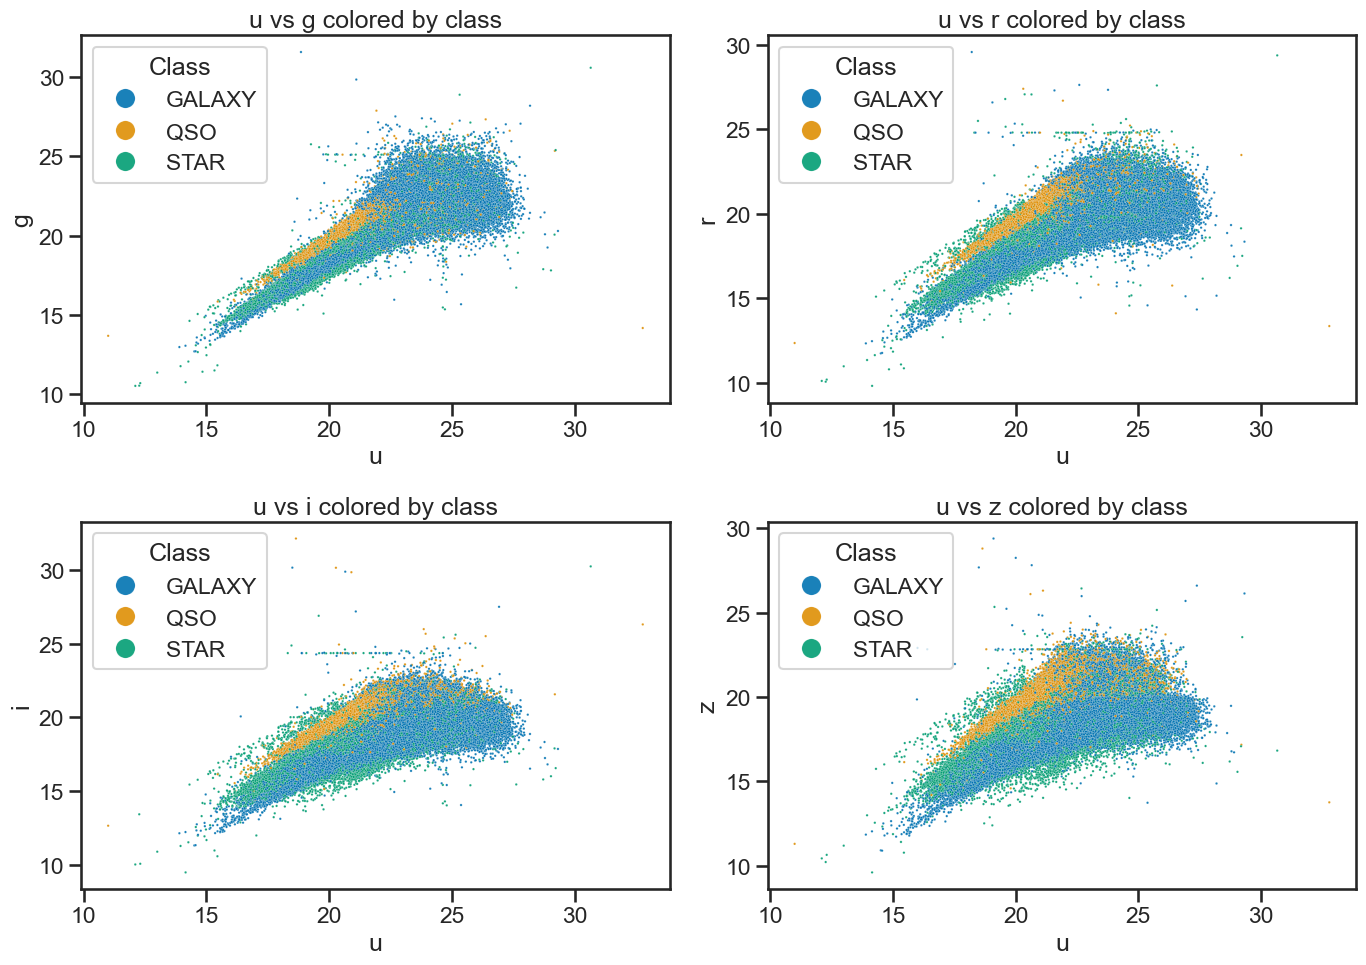

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# u vs g
sns.scatterplot(x='u', y='g', hue='class', data=df_stellar, ax=axes[0, 0], alpha=0.9, s=3)
axes[0, 0].set_xlabel('u')
axes[0, 0].set_ylabel('g')
axes[0, 0].set_title('u vs g colored by class')
axes[0, 0].legend(title='Class', loc='upper left', markerscale=8)

# u vs r
sns.scatterplot(x='u', y='r', hue='class', data=df_stellar, ax=axes[0, 1], alpha=0.9, s=3)
axes[0, 1].set_xlabel('u')
axes[0, 1].set_ylabel('r')
axes[0, 1].set_title('u vs r colored by class')
axes[0, 1].legend(title='Class', loc='upper left', markerscale=8)

# u vs i
sns.scatterplot(x='u', y='i', hue='class', data=df_stellar, ax=axes[1, 0], alpha=0.9, s=3)
axes[1, 0].set_xlabel('u')
axes[1, 0].set_ylabel('i')
axes[1, 0].set_title('u vs i colored by class')
axes[1, 0].legend(title='Class', loc='upper left', markerscale=8)

# u vs z
sns.scatterplot(x='u', y='z', hue='class', data=df_stellar, ax=axes[1, 1], alpha=0.9, s=3)
axes[1, 1].set_xlabel('u')
axes[1, 1].set_ylabel('z')
axes[1, 1].set_title('u vs z colored by class')
axes[1, 1].legend(title='Class', loc='upper left', markerscale=8)

plt.tight_layout()
plt.savefig('figures/stellar_color_diagrams.png', dpi=300)
plt.show()

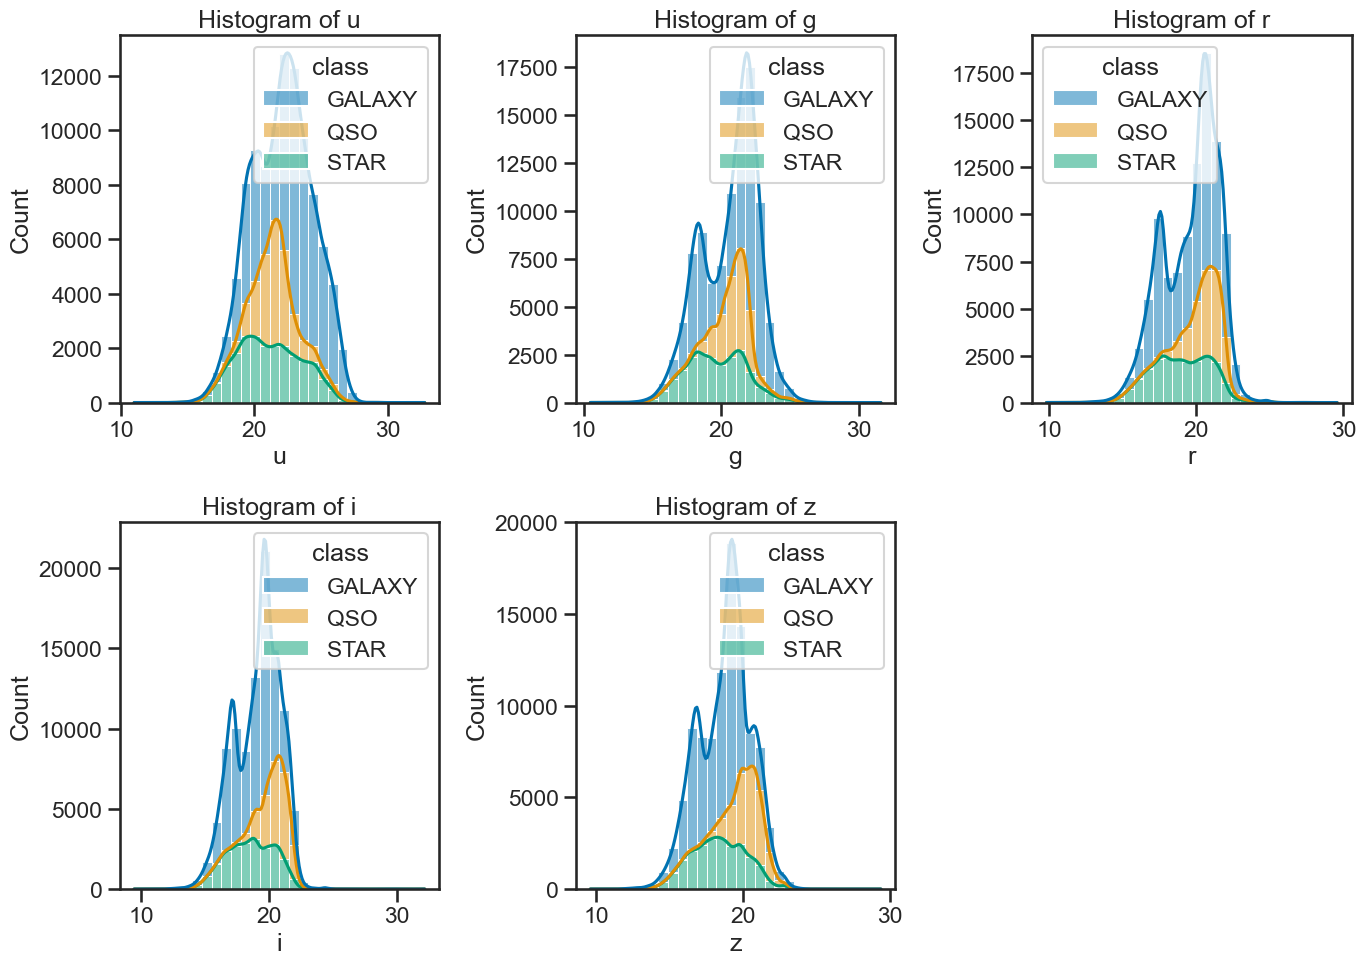

In [4]:
# create subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# plot histograms for each band with KDE
sns.histplot(data=df_stellar, x='u', hue='class', multiple='stack', ax=axes[0, 0], bins=30, kde=True)
sns.histplot(data=df_stellar, x='g', hue='class', multiple='stack', ax=axes[0, 1], bins=30, kde=True)
sns.histplot(data=df_stellar, x='r', hue='class', multiple='stack', ax=axes[0, 2], bins=30, kde=True)
sns.histplot(data=df_stellar, x='i', hue='class', multiple='stack', ax=axes[1, 0], bins=30, kde=True)
sns.histplot(data=df_stellar, x='z', hue='class', multiple='stack', ax=axes[1, 1], bins=30, kde=True)

axes[1, 2].axis('off')  # Hide the empty subplot

# set titles for each subplot
axes[0, 0].set_title('Histogram of u')
axes[0, 1].set_title('Histogram of g')
axes[0, 2].set_title('Histogram of r')
axes[1, 0].set_title('Histogram of i')
axes[1, 1].set_title('Histogram of z')

plt.tight_layout()
plt.savefig('figures/stellar_histograms.png', dpi=300)  # Save the figure
plt.show()

In [5]:
### your code here

In [6]:
### your code here

/var/folders/qv/mnq6bff11kbfx3jwqvl1w12m0000gn/T/ipykernel_41389/2213807954.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([f"{cls}\n({percentages[cls]:.1f}%)" for cls in class_counts.index])
/var/folders/qv/mnq6bff11kbfx3jwqvl1w12m0000gn/T/ipykernel_41389/2213807954.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([f"{label}\n({percentages_no_galaxy[label]:.1f}%)" for label in tick_labels])


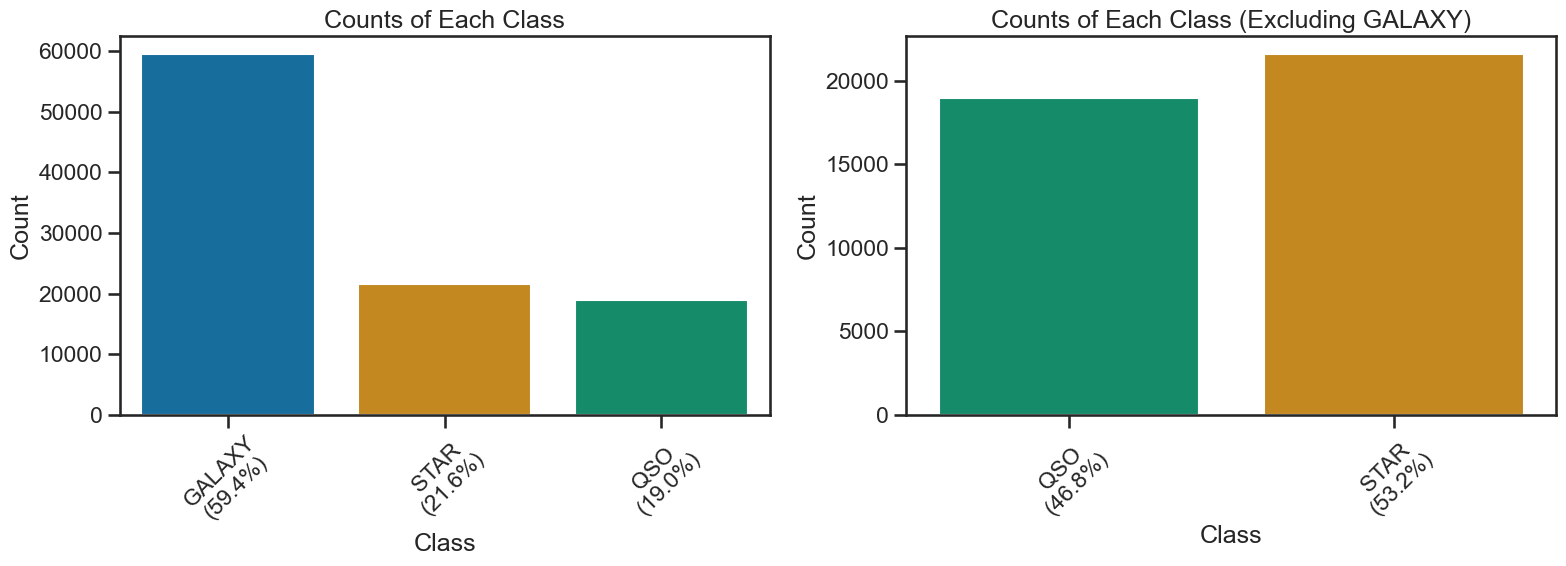

In [7]:
# Run this code to ensure you have the new DataFrame

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# All classes
class_counts = df_stellar['class'].value_counts()
percentages = df_stellar['class'].value_counts(normalize=True) * 100
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='colorblind', legend=False, ax=axs[0])
axs[0].set_xticklabels([f"{cls}\n({percentages[cls]:.1f}%)" for cls in class_counts.index])
axs[0].set_title('Counts of Each Class')
axs[0].set_xlabel('Class')
axs[0].set_ylabel('Count')
axs[0].tick_params(axis='x', rotation=45)

# Excluding GALAXY
df_no_galaxies = df_stellar[df_stellar['class'] != 'GALAXY']
percentages_no_galaxy = df_no_galaxies['class'].value_counts(normalize=True) * 100

# Use colorblind palette but skip the reverse order to make sure labels are same as colors in both plots
palette_no_galaxy = sns.color_palette('colorblind')[2:0:-1]

ax2 = sns.countplot(x='class', data=df_no_galaxies, hue='class', palette=palette_no_galaxy, ax=axs[1], legend=False)
tick_labels = [tick.get_text() for tick in ax2.get_xticklabels()]
ax2.set_xticklabels([f"{label}\n({percentages_no_galaxy[label]:.1f}%)" for label in tick_labels])
ax2.set_title('Counts of Each Class (Excluding GALAXY)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
## Import necessary libraries for the classification model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features  and target variable
X = df_no_galaxies[['u', 'g', 'r', 'i', 'z']]
y = df_no_galaxies['class']

In [9]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Create and train the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = knn_classifier.predict(X_test_scaled)

In [12]:
# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix

# Print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         QSO       0.86      0.85      0.85      3803
        STAR       0.87      0.87      0.87      4308

    accuracy                           0.86      8111
   macro avg       0.86      0.86      0.86      8111
weighted avg       0.86      0.86      0.86      8111



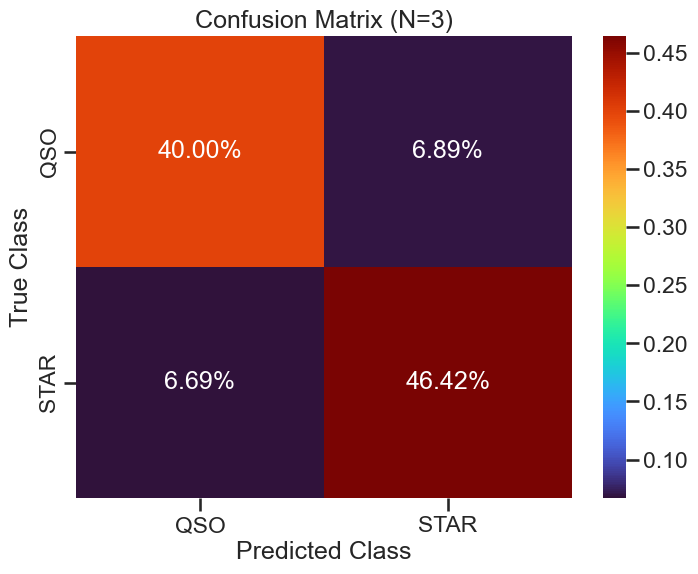

In [13]:
conf_matrix = confusion_matrix(y_test, y_pred)

def plot_confusion_matrix(conf_matrix, classes, N=0, filename=None):
    plt.figure(figsize=(8, 6))
    conf_matrix_prop = conf_matrix / conf_matrix.sum()
    sns.heatmap(conf_matrix_prop, annot=True, fmt='.2%', cmap='turbo',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix (N={N})')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(conf_matrix, knn_classifier.classes_, 3, './figures/confusion_matrix_knn_n3.png')

In [14]:
def get_classification_dfs(X_test, y_test, y_pred):
    """
    Create DataFrames for correctly and misclassified points.

    Parameters
    ----------
    X_test : pd.DataFrame
        Test set features.
    y_test : pd.Series or np.ndarray
        True class labels for the test set.
    y_pred : np.ndarray
        Predicted class labels for the test set.

    Returns
    -------
    df : pd.DataFrame
        DataFrame with test features, true class, and predicted class.
    misclassified : pd.DataFrame
        DataFrame with only misclassified samples.
    """
    df = X_test.copy()
    df['true_class'] = y_test
    df['predicted_class'] = y_pred
    misclassified = df[df['true_class'] != df['predicted_class']]
    return df, misclassified

In [15]:
# Prepare data for plotting
correctly_classified_df, misclassified_df = get_classification_dfs(X_test, y_test, y_pred)

In [16]:
### your code here

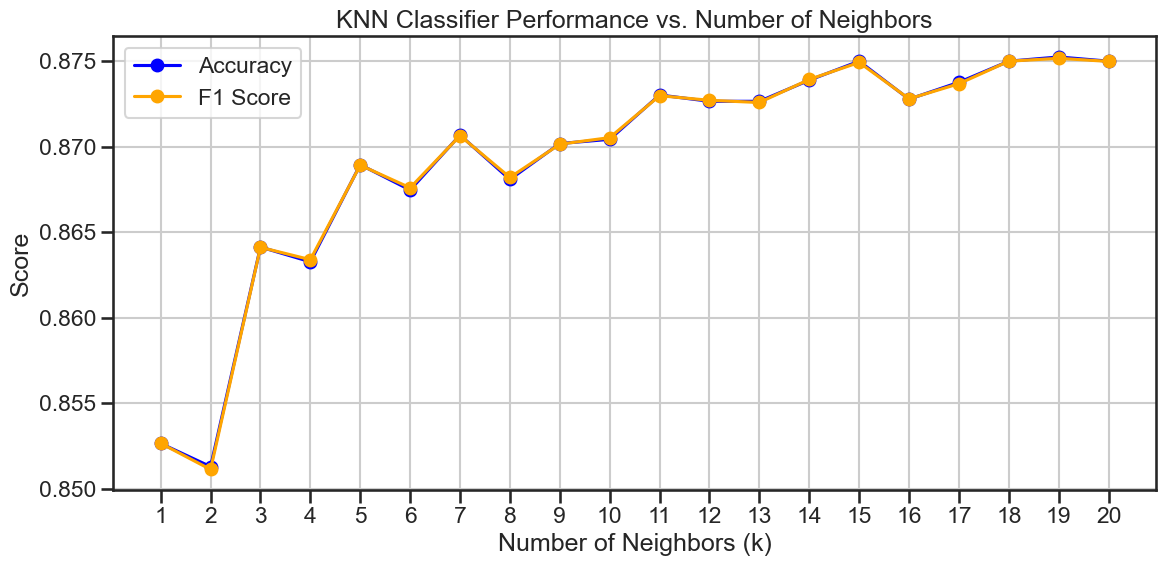

In [17]:
def knn_performance_vs_neighbors(X_train_scaled, y_train, X_test_scaled, y_test, k_range=range(1, 21)):
    from sklearn.metrics import accuracy_score, f1_score
    accuracies = []
    f1_scores = []
    for k in k_range:
        knn_classifier = KNeighborsClassifier(n_neighbors=k)
        knn_classifier.fit(X_train_scaled, y_train)
        y_pred = knn_classifier.predict(X_test_scaled)
        accuracies.append(accuracy_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred, average='weighted'))
    return list(k_range), accuracies, f1_scores

def plot_knn_performance(neighbors, accuracies, f1_scores, filename=None):
    plt.figure(figsize=(12, 6))
    plt.plot(neighbors, accuracies, marker='o', label='Accuracy', color='blue')
    plt.plot(neighbors, f1_scores, marker='o', label='F1 Score', color='orange')
    plt.title('KNN Classifier Performance vs. Number of Neighbors')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Score')
    plt.xticks(neighbors)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

neighbors, accuracies, f1_scores = knn_performance_vs_neighbors(X_train_scaled, y_train, X_test_scaled, y_test)
plot_knn_performance(neighbors, accuracies, f1_scores, './figures/knn_performance_vs_neighbors.png')

In [18]:
### your code here

In [19]:
### your code here

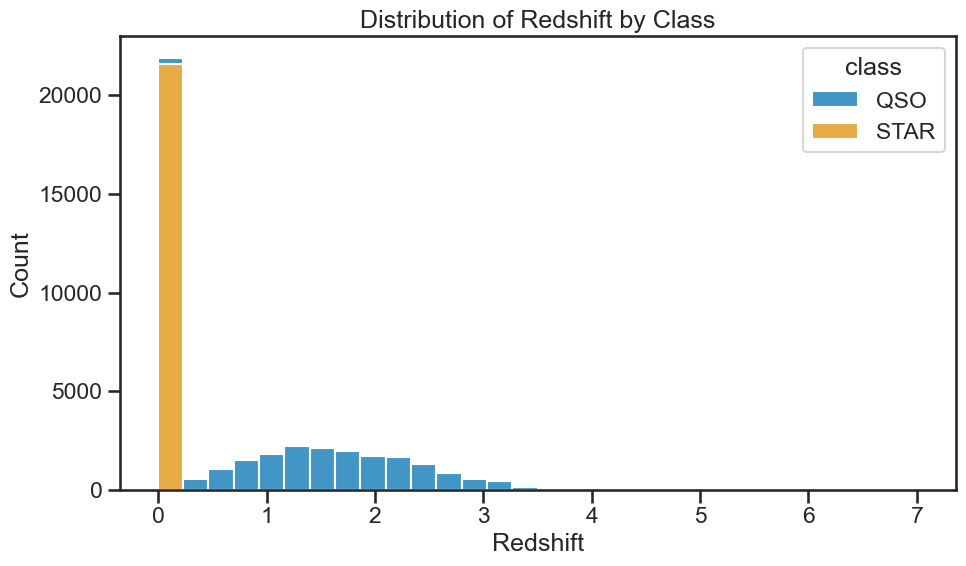

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_no_galaxies, x='redshift', hue='class', multiple='stack', bins=30)
plt.title('Distribution of Redshift by Class')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('./figures/histogram_redshift_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
### your code here

In [22]:
### your code here

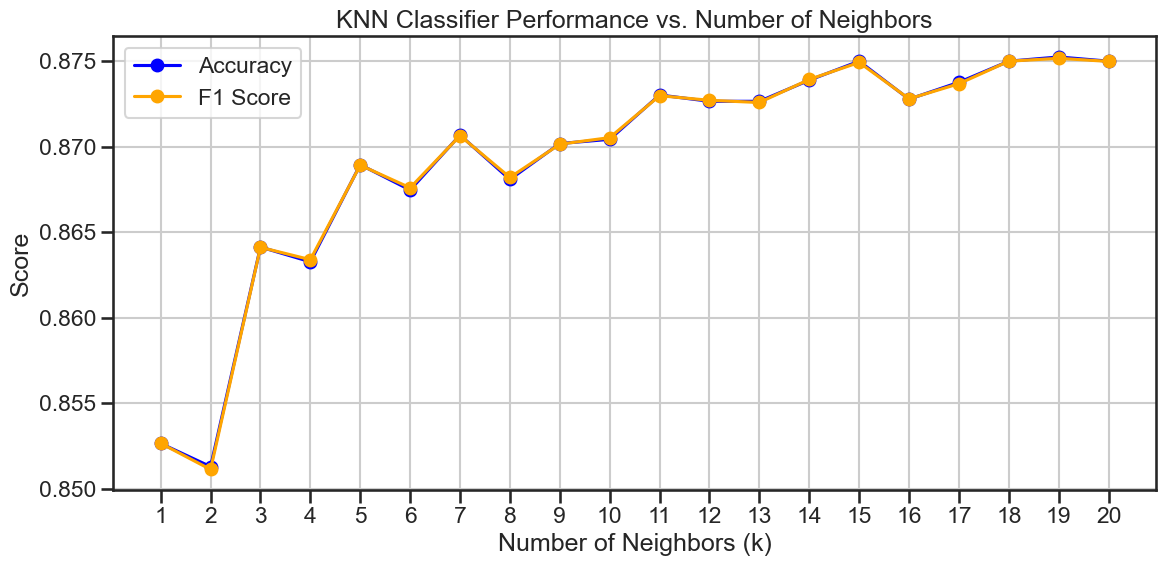

In [23]:
neighbors, accuracies, f1_scores = knn_performance_vs_neighbors(X_train_scaled, y_train, X_test_scaled, y_test)
plot_knn_performance(neighbors, accuracies, f1_scores, './figures/knn_w_redshit_performance_vs_neighbors.png')

In [24]:
df_stellar['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [25]:
### your code here

In [26]:
### your code here

In [27]:
### your code here